In [1]:
#Importing and viewing the data
import pandas as pd
import matplotlib.pyplot as plt
import pygal
import warnings
warnings.filterwarnings('ignore')

hotdog = pd.read_excel('hotdog-places.xlsm')
hotdog_winners = pd.read_excel('hotdog-contest-winners.xlsm')
obama = pd.read_excel('obama-approval-ratings.xls')
print(hotdog, '\n')
print(hotdog_winners, '\n')
print(obama)

   2000  2001  2002  2003  2004  2005  2006  2007  2008  2009  2010
0    25  50.0  50.5  44.5  53.5    49    54    66    59  68.0    54
1    24  31.0  26.0  30.5  38.0    37    52    63    59  64.5    43
2    22  23.5  25.5  29.5  32.0    32    37    49    42  55.0    37 

    Year                        Winner  Dogs eaten        Country  New record
0   1980  Paul Siederman & Joe Baldini        9.10  United States           0
1   1981               Thomas DeBerry        11.00  United States           0
2   1982                Steven Abrams        11.00  United States           0
3   1983                  Luis Llamas        19.50         Mexico           0
4   1984                Birgit Felden         9.50        Germany           0
5   1985              Oscar Rodriguez        11.75  United States           0
6   1986                  Mark Heller        15.50  United States           0
7   1987                  Don Wolfman        12.00  United States           0
8   1988                

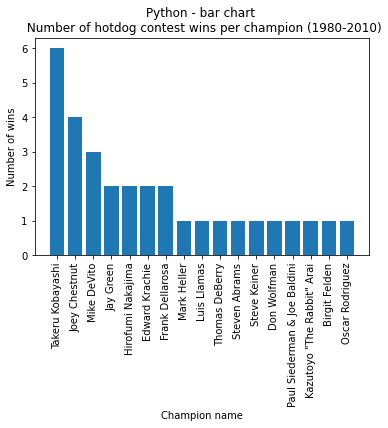

In [2]:
#Constructing the bar chart using the second dataset. 
#For each champion in the dataset, I will show the number of wins to their name from 1980-2010.

#First, row 27 must be changed, as Takeru Kobayashi's name has an extra word in it.
hotdog_winners['Winner'][26] = hotdog_winners['Winner'][26].replace('Takeru "Tsunami" Kobayashi ', 'Takeru Kobayashi ')

#Leading and trailing whitespaces are then removed from the winner column
hotdog_winners['Winner'] = hotdog_winners['Winner'].str.strip()

#Generating the bar chart with matplotlib
wins_per_person = hotdog_winners['Winner'].value_counts()
winners = wins_per_person.index
plt.bar(winners, wins_per_person)
plt.xlabel('Champion name')
plt.ylabel('Number of wins')
plt.title('Python - bar chart \n Number of hotdog contest wins per champion (1980-2010)')
plt.xticks(rotation = 90)
plt.show()

#It looks like Takeru Kobayashi had the most wins among the champions, followed by Joey Chestnut and Mike DeVito.

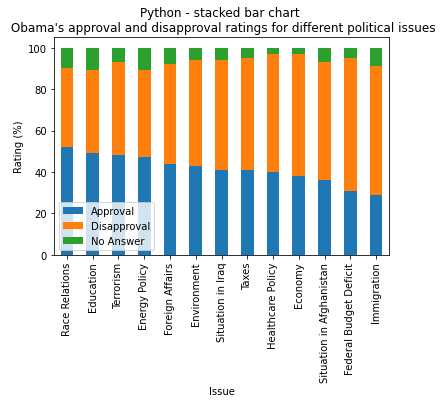

In [3]:
#Constructing the stacked bar chart using the third dataset.
#For each political issue, I will show the approval, disapproval, and non-answer percentages.

#Separating out the dataset
issues = obama['Issue']
approval = obama['Approve']
disapproval = obama['Disapprove']
none = obama['None']

#Using Pandas to generate a stacked bar chart
df = pd.DataFrame({'Issue' : issues, 'Approval' : approval, 'Disapproval' : disapproval, 'No Answer' : none})
df.index = issues
df.plot.bar(stacked = True)
plt.xlabel('Issue')
plt.ylabel('Rating (%)')
plt.title("Python - stacked bar chart \n Obama's approval and disapproval ratings for different political issues")
plt.show()

#It looks like Obama had the highest approval rating for his race relations 
#and the highest disapproval rating for his immigration policies.

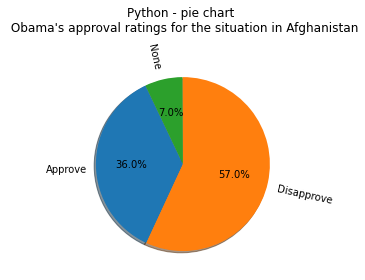

In [4]:
#Constructing the pie chart using the third dataset.
#I will show Obama's approval ratings for one issue, the situation in Afghanistan.

#Separating out the data
ind = obama[obama['Issue'] == 'Situation in Afghanistan'].values[0]
pielist = []
for i in ind:
    if str(i).isnumeric() == True:
        pielist.append(i)


#Generating the pie chart with matplotlib
fig, ax = plt.subplots()
labels = obama.columns[1:4]
ax.pie(pielist, labels = labels, autopct = '%1.1f%%', shadow = True, startangle = 115.5, rotatelabels = True)
plt.title("Python - pie chart \n Obama's approval ratings for the situation in Afghanistan", y = 1.08)
plt.show()

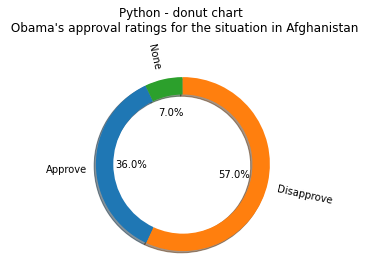

In [5]:
#Constructing a donut chart using the same data as above 
#Since a donut chart is simply a pie chart with the center removed, I will remake the above pie chart but remove the center.

fig, ax = plt.subplots()
labels = obama.columns[1:4]
ax.pie(pielist, labels = labels, wedgeprops = {'width' : 0.2}, autopct = '%1.1f%%', shadow = True, startangle = 115.5, rotatelabels = True)
plt.title("Python - donut chart \n Obama's approval ratings for the situation in Afghanistan", y = 1.08)
plt.show()
